In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv('Titanic-Dataset.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head(10)

Dataset loaded successfully!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
print("=== Dataset Information ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

=== Missing Values ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare            

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


=== Survival Distribution ===
Survived
0    549
1    342
Name: count, dtype: int64

Survival Rate: 38.38%


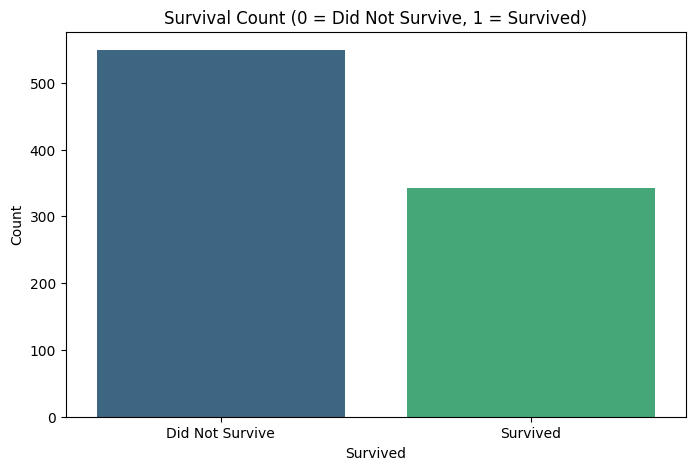

=== Survival Distribution ===
Survived
0    549
1    342
Name: count, dtype: int64

Survival Rate: 38.38%


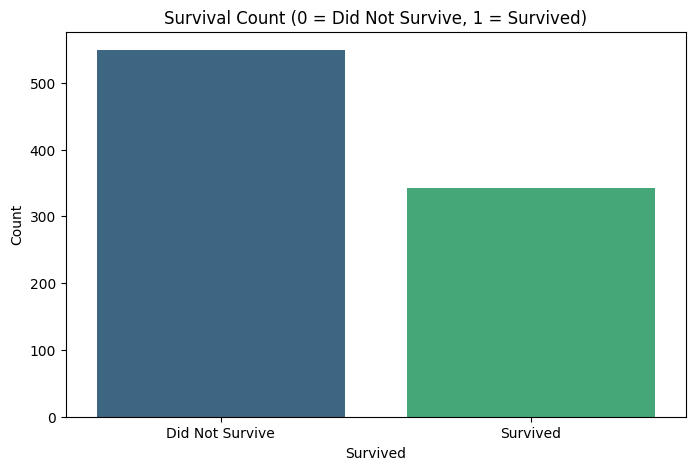

In [5]:
print("=== Survival Distribution ===")
print(df['Survived'].value_counts())
print(f"\nSurvival Rate: {df['Survived'].mean()*100:.2f}%")

plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Survival Count (0 = Did Not Survive, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.show()

=== Survival by Gender ===
Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64


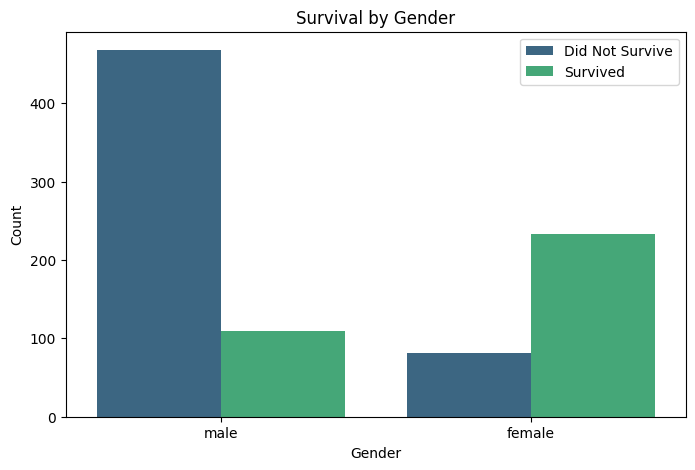

In [6]:
print("=== Survival by Gender ===")
print(df.groupby('Sex')['Survived'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', hue='Survived', data=df, palette='viridis')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

=== Survival by Passenger Class ===
Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64


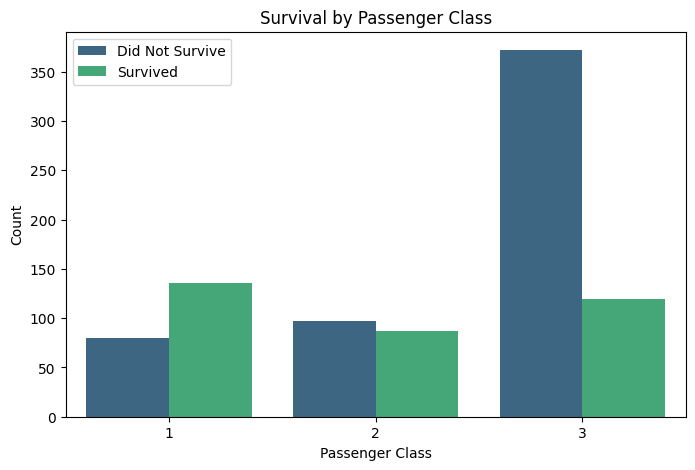

In [7]:
print("=== Survival by Passenger Class ===")
print(df.groupby('Pclass')['Survived'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='viridis')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

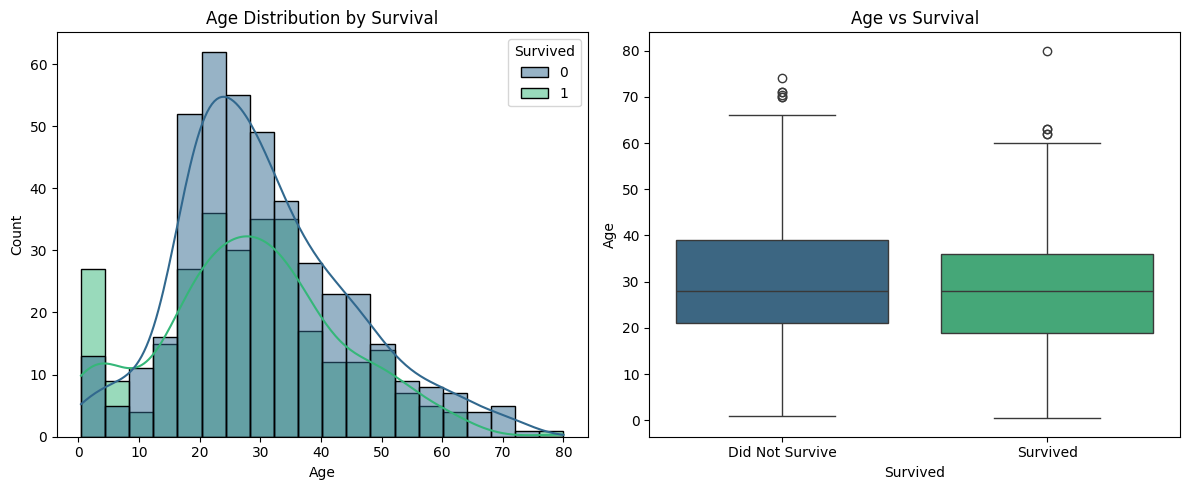

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', hue='Survived', kde=True, palette='viridis')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')

plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Age', data=df, palette='viridis')
plt.title('Age vs Survival')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])

plt.tight_layout()
plt.show()

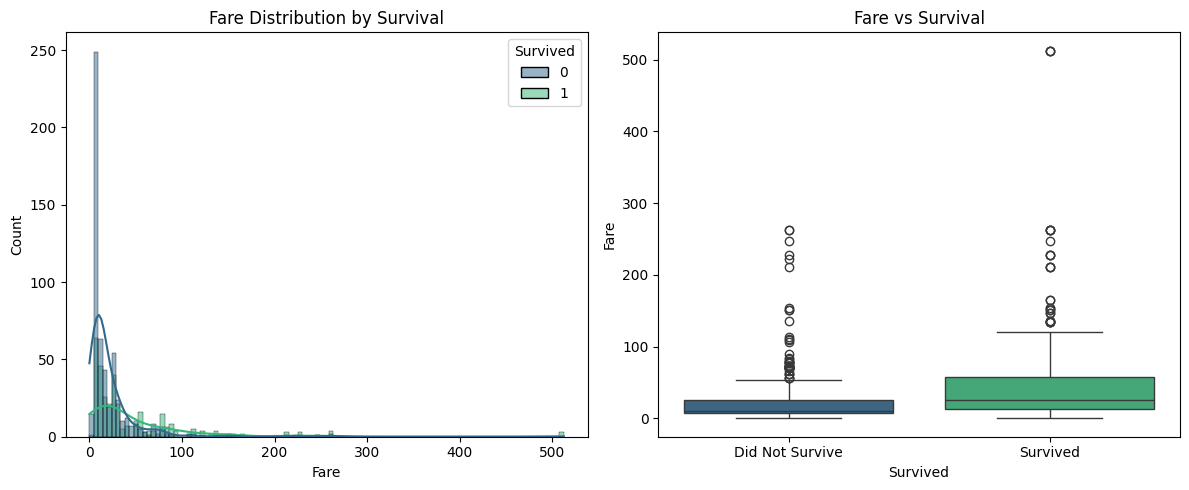

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Fare', hue='Survived', kde=True, palette='viridis')
plt.title('Fare Distribution by Survival')
plt.xlabel('Fare')

plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Fare', data=df, palette='viridis')
plt.title('Fare vs Survival')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])

plt.tight_layout()
plt.show()

=== Survival by Embarked Port ===
Embarked  Survived
C         1            93
          0            75
Q         0            47
          1            30
S         0           427
          1           217
Name: count, dtype: int64


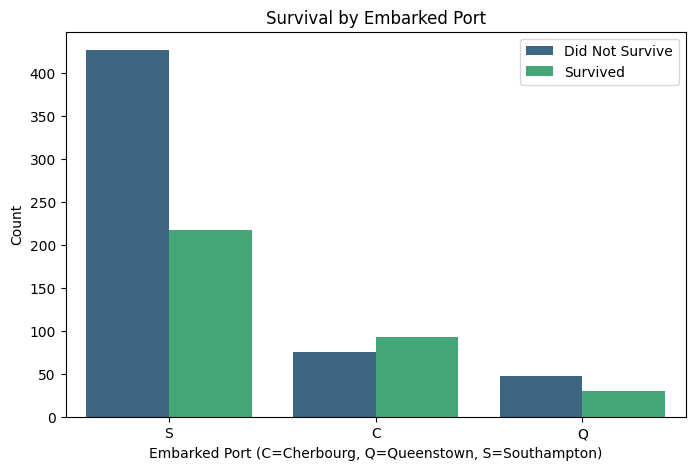

In [10]:
print("=== Survival by Embarked Port ===")
print(df.groupby('Embarked')['Survived'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x='Embarked', hue='Survived', data=df, palette='viridis')
plt.title('Survival by Embarked Port')
plt.xlabel('Embarked Port (C=Cherbourg, Q=Queenstown, S=Southampton)')
plt.ylabel('Count')
plt.legend(['Did Not Survive', 'Survived'])
plt.show()

=== Family Size Distribution ===
FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64


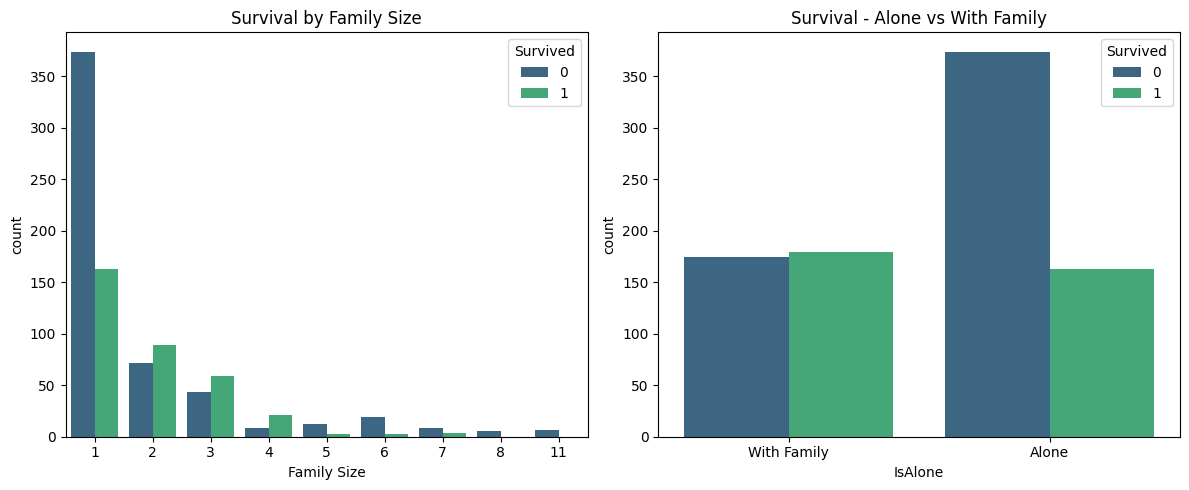

In [11]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("=== Family Size Distribution ===")
print(df['FamilySize'].value_counts())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='FamilySize', hue='Survived', data=df, palette='viridis')
plt.title('Survival by Family Size')
plt.xlabel('Family Size')

plt.subplot(1, 2, 2)
sns.countplot(x='IsAlone', hue='Survived', data=df, palette='viridis')
plt.title('Survival - Alone vs With Family')
plt.xticks([0, 1], ['With Family', 'Alone'])

plt.tight_layout()
plt.show()

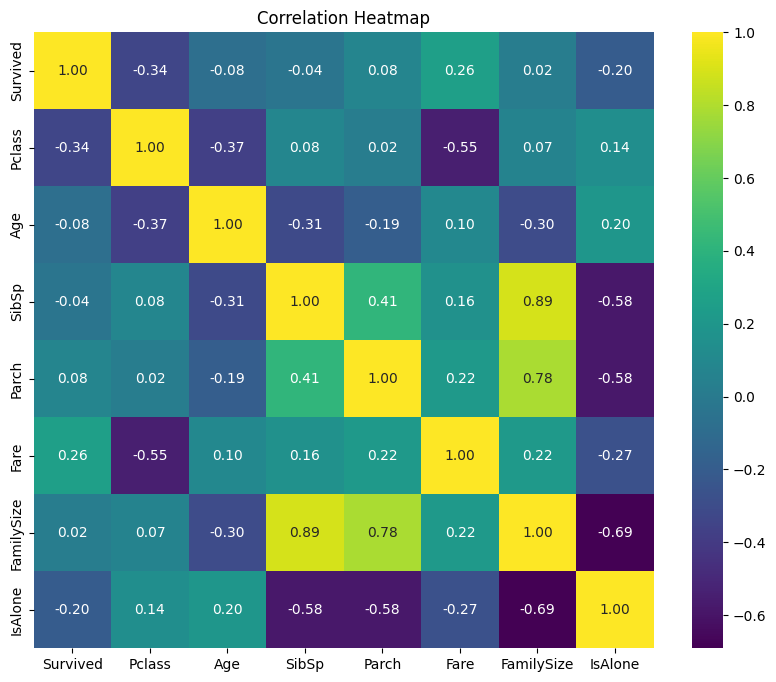

In [12]:
plt.figure(figsize=(10, 8))
numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [13]:
# dropping unnecessary columns
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# filling missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)

# encoding categorical columns
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

print("=== Data After Preprocessing ===")
print("Missing Values:\n", df.isnull().sum())
print("\nShape:", df.shape)
df.head(10)

=== Data After Preprocessing ===
Missing Values:
 Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
dtype: int64

Shape: (891, 10)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,1,22.0,1,0,7.2500,2,2,0
1,1,1,0,38.0,1,0,71.2833,0,2,0
2,1,3,0,26.0,0,0,7.9250,2,1,1
3,1,1,0,35.0,1,0,53.1000,2,2,0
4,0,3,1,35.0,0,0,8.0500,2,1,1
5,0,3,1,28.0,0,0,8.4583,1,1,1
6,0,1,1,54.0,0,0,51.8625,2,1,1
7,0,3,1,2.0,3,1,21.0750,2,5,0
8,1,3,0,27.0,0,2,11.1333,2,3,0
9,1,2,0,14.0,1,0,30.0708,0,2,0


In [14]:
X = df.drop('Survived', axis=1)
y = df['Survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Total samples: {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nFeatures used: {list(X.columns)}")
print(f"Target: Survived")

Total samples: 891
Training samples: 712
Testing samples: 179

Features used: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']
Target: Survived


In [15]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print("=== Logistic Regression ===")
print(f"Accuracy: {lr_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

=== Logistic Regression ===
Accuracy: 79.89%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [16]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print("=== Decision Tree ===")
print(f"Accuracy: {dt_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

=== Decision Tree ===
Accuracy: 78.21%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       105
           1       0.73      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179



In [17]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print("=== K-Nearest Neighbors ===")
print(f"Accuracy: {knn_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

=== K-Nearest Neighbors ===
Accuracy: 81.56%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



In [18]:
svm = SVC(random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print("=== Support Vector Machine ===")
print(f"Accuracy: {svm_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

=== Support Vector Machine ===
Accuracy: 81.56%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("=== Random Forest ===")
print(f"Accuracy: {rf_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

=== Random Forest ===
Accuracy: 81.56%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



In [20]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)

print("=== Gradient Boosting ===")
print(f"Accuracy: {gb_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

=== Gradient Boosting ===
Accuracy: 80.45%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.70      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



=== Model Comparison ===
              Model  Accuracy
Logistic Regression     79.89
      Decision Tree     78.21
                KNN     81.56
                SVM     81.56
      Random Forest     81.56
  Gradient Boosting     80.45

Best Model: KNN
Best Accuracy: 81.56%


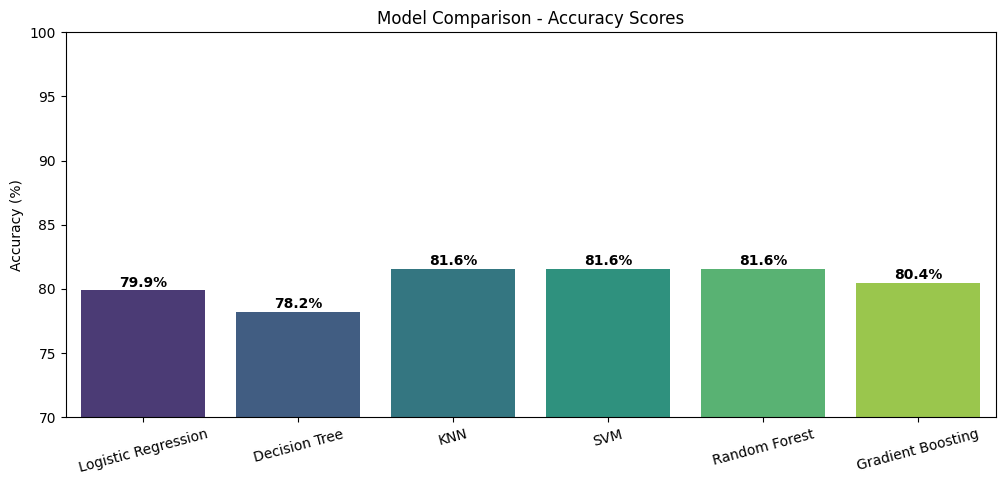

In [21]:
models = ['Logistic Regression', 'Decision Tree', 'KNN', 'SVM', 'Random Forest', 'Gradient Boosting']
accuracies = [lr_acc, dt_acc, knn_acc, svm_acc, rf_acc, gb_acc]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': [round(a*100, 2) for a in accuracies]
})

print("=== Model Comparison ===")
print(comparison_df.to_string(index=False))
print(f"\nBest Model: {models[accuracies.index(max(accuracies))]}")
print(f"Best Accuracy: {max(accuracies)*100:.2f}%")

plt.figure(figsize=(12, 5))
sns.barplot(x=models, y=[a*100 for a in accuracies], palette='viridis')
plt.title('Model Comparison - Accuracy Scores')
plt.ylabel('Accuracy (%)')
plt.ylim(70, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v*100 + 0.3, f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.show()

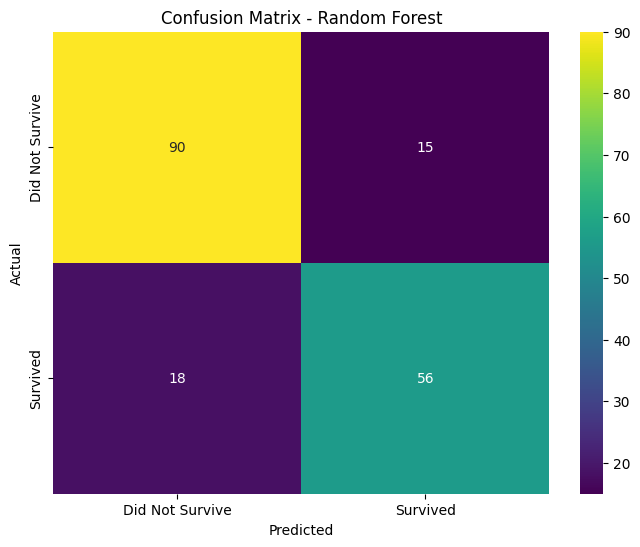

In [22]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

=== Feature Importance ===
   Feature  Importance Score
       Sex          0.281250
      Fare          0.255096
       Age          0.246047
    Pclass          0.086759
FamilySize          0.044755
  Embarked          0.031321
     SibSp          0.026913
     Parch          0.019532
   IsAlone          0.008327


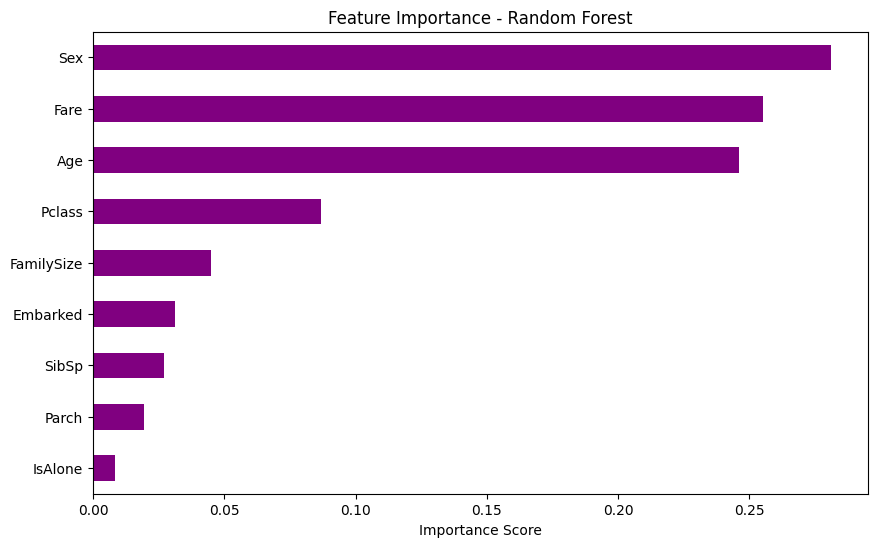

In [23]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance_df = importance.sort_values(ascending=False).reset_index()
importance_df.columns = ['Feature', 'Importance Score']

print("=== Feature Importance ===")
print(importance_df.to_string(index=False))

importance.sort_values().plot(kind='barh', color='purple', figsize=(10, 6))
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

In [24]:
new_passenger = pd.DataFrame({
    'Pclass': [3],
    'Sex': [1],
    'Age': [22],
    'SibSp': [1],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked': [2],
    'FamilySize': [2],
    'IsAlone': [0]
})

new_passenger_scaled = scaler.transform(new_passenger)
prediction = rf.predict(new_passenger_scaled)

print("=== New Passenger Survival Prediction ===")
print(f"Passenger Class: 3rd")
print(f"Gender: Male")
print(f"Age: 22")
print(f"Siblings/Spouse: 1")
print(f"Parents/Children: 0")
print(f"Fare: $7.25")
print(f"Embarked: Southampton")
print(f"\nPrediction: {'Survived ✅' if prediction[0] == 1 else 'Did Not Survive ❌'}")

=== New Passenger Survival Prediction ===
Passenger Class: 3rd
Gender: Male
Age: 22
Siblings/Spouse: 1
Parents/Children: 0
Fare: $7.25
Embarked: Southampton

Prediction: Did Not Survive ❌
